# Merged Notebook: Schweinehaltungs-Klassifikation (PLF)

**Projekt:** Deep Learning in der Präzisions-Nutztierhaltung (Precision Livestock Farming)  
**Wettbewerb:** [Multi-View Pig Posture Recognition](https://www.kaggle.com/competitions/multi-view-pig-posture-recognition) – Michigan State University  
**Autoren:** Fabio, Lara, Yusuf  
**Bewertungsmetrik:** Macro-averaged F1-Score

---

## Was ist das Ziel?

Schweine in Stallkameras werden automatisch in eine von fünf Haltungsklassen eingeordnet. Die Klassen:

| ID | Klasse | Bedeutung |
|----|--------|-----------|
| 0 | Lateral_lying_left | Seitenlage links |
| 1 | Lateral_lying_right | Seitenlage rechts |
| 2 | Sitting | Sitzen |
| 3 | Standing | Stehen |
| 4 | Sternal_lying | Bauchlage |

Für jedes Schwein im Bild ist bereits eine Bounding Box vorgegeben. Das Modell soll aus diesem Ausschnitt die Haltung erkennen.

## Warum Macro-F1?

Die Klassen sind stark ungleich verteilt (Standing hat ~9.600 Einträge, Sitting nur ~680). Ein Modell, das einfach immer "Standing" vorhersagt, würde trotzdem hohe Genauigkeit erreichen. Der Macro-F1-Score behandelt jede Klasse gleichwertig und bestraft das Ignorieren seltener Klassen.

---

## Methodischer Rahmen: CRISP-DM

Dieses Notebook folgt dem CRISP-DM-Prozessmodell (Cross-Industry Standard Process for Data Mining), das den Ablauf eines Data-Mining- oder ML-Projekts in sechs Phasen gliedert:

| CRISP-DM Phase | Abschnitt in diesem Notebook |
|----------------|------------------------------|
| 1. Business Understanding | Projektziel, Bewertungsmetrik, Business Value |
| 2. Data Understanding | EDA: Klassenverteilung, Kameraanalyse, Beispielbilder |
| 3. Data Preparation | PigCropDataset, Augmentation, GroupShuffleSplit |
| 4. Modeling | Architekturwahl, FocalLoss, Two-Phase Training |
| 5. Evaluation | Classification Report, Konfusionsmatrix |
| 6. Deployment | TTA-Inference, Submission-Generierung |

Die Phasen sind jeweils durch Überschriften im Notebook markiert.

---

## Business Value und Tierschutz (CRISP-DM Phase 1)

Die automatische Haltungserkennung hat direkten Nutzen für das Tierwohl:

- **Früherkennung von Krankheiten:** Verändertes Liegeverhalten (z.B. ungewöhnlich langer Aufenthalt in Seitenlage) kann auf Erkrankungen hinweisen, bevor äußere Symptome sichtbar sind.
- **Zeatersparnis:** Ein Landwirt mit 500 Schweinen könnte manuell kaum jeden Tag alle Tiere beobachten. Ein automatisches System läuft rund um die Uhr.
- **Dokumentation:** Haltungsdaten können als Grundlage für Tierschutzberichte und Qualitätsnachweise dienen.

Aus technischer Sicht gilt: Ein Modell, das seltene Haltungen (z.B. Sitting) zuverlässig erkennt, erkennt damit auch ungewöhnliche Körperlagen, die auf gesundheitliche Probleme hinweisen können.

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from tqdm.notebook import tqdm
from training_monitor import TrainingMonitor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print('Alle Bibliotheken geladen.')


<jemalloc>: Unsupported system page size


Alle Bibliotheken geladen.


## Konfiguration und Reproduzierbarkeit

Ein zentrales Konfigurationsobjekt hat mehrere Vorteile:
- Alle Hyperparameter sind an einem Ort sichtbar
- Änderungen müssen nur einmal gemacht werden
- Das Notebook lässt sich leicht für andere Datensätze anpassen

**Warum `SEED = 42`?**  
Ohne feste Seeds hängen Ergebnisse vom Zufall ab. Zwei Läufe desselben Codes können dann unterschiedliche Ergebnisse liefern, was Vergleiche zwischen Experimenten wertlos macht. Durch feste Seeds sind alle Zufallsprozesse (Datensplit, Gewichtsinitialisierung, Dropout) reproduzierbar.

**Warum `IMAGE_SIZE = 384`?**  
Frühe Experimente haben gezeigt, dass 224x224 Pixel zu wenig Detailinformation enthalten, besonders für kleine Bounding Boxes. 384x384 bietet deutlich mehr Detail bei noch vertretbarem VRAM-Verbrauch.

In [2]:
# Reproduzierbarkeit: alle Zufallsgeneratoren auf denselben Zustand setzen
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # benchmark=False ist Pflicht bei deterministic=True


DATA_DIR         = '/datasets/multi-view-pig-posture-recognition'
TRAIN2_IMAGE_DIR = os.path.join(DATA_DIR, 'train2_images')
TEST_IMAGE_DIR   = os.path.join(DATA_DIR, 'test_images')


IMAGE_SIZE = 384
BATCH_SIZE = 128
NUM_CLASSES = 5
NUM_WORKERS = 8
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count()

CLASS_NAMES = [
    'Lateral_lying_left',
    'Lateral_lying_right',
    'Sitting',
    'Standing',
    'Sternal_lying'
]

## CRISP-DM Phase 2: Data Understanding

### Daten laden

Der Datensatz besteht aus zwei Trainingsmengen und einem Testset:

- **Train Set 1 (T1):** Training auf bekannten Kameras, Evaluation auf völlig unbekannten Perspektiven und Tiergruppen. Höchste Generalisierungsanforderung.
- **Train Set 2 (T2):** Ein kleiner Anteil der Testkameras ist bereits im Training enthalten. Ermöglicht begrenzte Domänenanpassung.
- **Test Set:** Die Bilder, für die Vorhersagen abgegeben werden.

Jede Zeile in den CSV-Dateien repräsentiert eine Schwein-Instanz (Bounding Box) in einem Bild.

Das Format der Bounding Box ist `[x_min, y_min, width, height]` in Pixeln.

In [3]:
train1_df = pd.read_csv(os.path.join(DATA_DIR, 'train1.csv'))
train2_df = pd.read_csv(os.path.join(DATA_DIR, 'train2.csv'))
test_df   = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

def parse_bbox(bbox_str):
    '''Konvertiert Bounding-Box-String [x, y, w, h] in eine Liste von Floats.'''
    return list(map(float, str(bbox_str).strip('[]').split(',')))

for df in [train1_df, train2_df, test_df]:
    df['bbox_parsed'] = df['bbox'].apply(parse_bbox)

print(f'Train1: {len(train1_df):>6} Einträge')
print(f'Train2: {len(train2_df):>6} Einträge')
print(f'Test:   {len(test_df):>6} Einträge')
print(f'\nSpalten: {list(train1_df.columns)}')
train1_df.head(3)

Train1:  22934 Einträge
Train2:  23450 Einträge
Test:    11708 Einträge

Spalten: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id', 'bbox_parsed']


,row_id,image_id,width,height,bbox,class_id,bbox_parsed
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0,"[1031.5, 368.0, 349.0, 435.0]"
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4,"[1278.5, 428.0, 233.0, 438.0]"
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1,"[732.0, 137.5, 342.0, 198.0]"


### Explorative Datenanalyse (EDA)

Vor dem ersten Modell müssen wir die Daten verstehen. Zwei Fragen sind besonders wichtig:

1. **Klassenverteilung:** Wie stark ist das Ungleichgewicht zwischen den Klassen?
2. **Kameraverteilung:** Wie viele verschiedene Perspektiven gibt es, und sind manche stark überrepräsentiert?

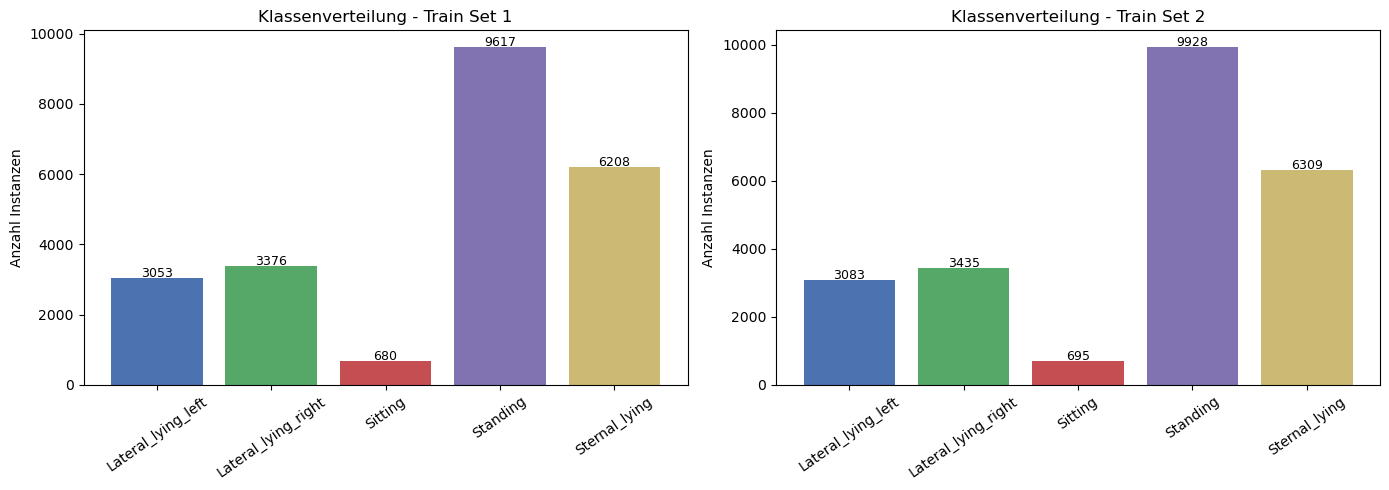


Klassenverteilung Train2 (absolut):
class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64

Klassenverteilung Train2 (relativ):
class_id
0    0.131
1    0.146
2    0.030
3    0.423
4    0.269
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(train1_df, 'Train Set 1'), (train2_df, 'Train Set 2')]):
    counts = df['class_id'].value_counts().sort_index()
    bar_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    bars = ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values, color=bar_colors)
    ax.set_title(f'Klassenverteilung - {title}', fontsize=12)
    ax.set_ylabel('Anzahl Instanzen')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('klassenverteilung.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nKlassenverteilung Train2 (absolut):')
print(train2_df['class_id'].value_counts().sort_index())
print('\nKlassenverteilung Train2 (relativ):')
print(train2_df['class_id'].value_counts(normalize=True).sort_index().round(3))

### Erkenntnisse aus der Klassenverteilung

Die Analyse zeigt ein deutliches Klassenungleichgewicht:

- Einträge mit **Standing** dominieren im Gegensatz zu anderen Klassen erheblich.
- **Sitting** ist die seltenste Klasse.

**Konsequenz für das Training:**  
Ohne Gegenmaßnahmen lernt das Modell, seltene Klassen zu ignorieren. Ein Modell, das nie 'Sitting' vorhersagt, erreicht trotzdem über 97% Genauigkeit. Deshalb werden wir:
1. **Klassengewichte** in der Verlustfunktion setzen (seltene Klassen erhalten höhere Strafe bei Fehlklassifikation).
2. Den **Macro-F1-Score** als Validierungsmetrik verwenden, nicht die Genauigkeit.

In [5]:
def extract_camera_info(image_id):
    '''
    Extrahiert strukturierte Kamerainformationen aus dem Dateinamen.
    Tatsächliches Format: pen1_orb_cam1_20250108_085204.jpg

    Warum frame_id? Mehrere Kameras nehmen denselben Stallbereich zum
    selben Zeitpunkt auf (Multi-View). Durch Entfernen der cam-Nummer
    erhalten synchrone Aufnahmen (z.B. cam1 und cam2 vom selben Zeitstempel)
    dieselbe frame_id -- GroupShuffleSplit hält sie dann in derselben
    Split-Hälfte und verhindert so Data Leakage.
    
    '''
    s = str(image_id)
    m_pen  = re.search(r'^(pen\d+)', s)
    m_type = re.search(r'_(orb|tur)_', s)
    m_num  = re.search(r'cam(\d+)', s)

    if m_pen and m_type and m_num:
        pen      = m_pen.group(1)
        cam_type = m_type.group(1)
        cam_num  = m_num.group(1)
        # frame_id: cam-Nummer entfernen, damit synchrone Multi-View-Aufnahmen
        # derselben Kamera-Gruppe (orb oder tur) im selben Split bleiben.
        frame_id = re.sub(r'_cam\d+', '', s)
        return {
            'pen_id':         pen,
            'camera_type':    cam_type,
            'camera_number':  cam_num,
            'camera_view_id': f'{pen}_{cam_type}_cam{cam_num}',
            'frame_id':       frame_id
        }
    # Fallback: Dateiname entspricht nicht dem erwarteten Schema.
    # frame_id = image_id: GroupShuffleSplit kann dennoch eine Gruppe zuweisen,
    # da alle Schweine desselben Bildes dieselbe image_id teilen.
    return {'pen_id': None, 'camera_type': None, 'camera_number': None,
            'camera_view_id': None, 'frame_id': str(image_id)}

for df in [train1_df, train2_df, test_df]:
    info = df['image_id'].apply(extract_camera_info).apply(pd.Series)
    for col in info.columns:
        df[col] = info[col]

# Wie viele Zeilen hatten keinen Regex-Match?
for _name, _df in [('Train1', train1_df), ('Train2', train2_df), ('Test', test_df)]:
    _no_match = _df['pen_id'].isna().sum()
    if _no_match > 0:
        print(f'Warnung ({_name}): {_no_match} Zeile(n) ohne Regex-Match -- frame_id = image_id gesetzt')

print(f'Eindeutige Kameraansichten in Train1: {train1_df["camera_view_id"].nunique()}')
print(f'Eindeutige Kameraansichten in Train2: {train2_df["camera_view_id"].nunique()}')
print(f'Eindeutige frame_ids in Train2: {train2_df["frame_id"].nunique()}')


Eindeutige Kameraansichten in Train1: 5
Eindeutige Kameraansichten in Train2: 8
Eindeutige frame_ids in Train2: 3084


In [6]:

print('=== Kameraverteilung Train Set 1 ===')
print(train1_df['camera_view_id'].value_counts().to_string())

print('\n=== Kameraverteilung Train Set 2 ===')
print(train2_df['camera_view_id'].value_counts().to_string())

=== Kameraverteilung Train Set 1 ===
camera_view_id
pen2_tur_cam1    9713
pen1_tur_cam2    8194
pen2_orb_cam1    2817
pen1_orb_cam2    1488
pen1_orb_cam1     722

=== Kameraverteilung Train Set 2 ===
camera_view_id
pen2_tur_cam1    9713
pen1_tur_cam2    8194
pen2_orb_cam1    2817
pen1_orb_cam2    1488
pen1_orb_cam1     722
pen1_tur_cam1     200
pen2_tur_cam2     196
pen2_orb_cam2     120


### Erkenntnisse aus der Kameraanalyse und Vergleich T1 vs. T2

Die Analyse zeigt, dass sowohl **Train Set 1** als auch **Train Set 2** von zwei Kameras massiv dominiert werden: 
* `pen2_tur_cam1` (9.713 Einträge)
* `pen1_tur_cam2` (8.194 Einträge)

Zusammen machen diese beiden Perspektiven **fast 80% des gesamten Datensatzes** aus. Das ist aus folgenden Gründen kritisch:

* **Kameraspezifischer Fokus:** Das Modell lernt überwiegend die visuellen Merkmale dieser zwei dominanten Kamerapositionen, während andere Blickwinkel stark unterrepräsentiert sind.
* **Eingeschränkte Abstraktion:** Wenn das Modell primär auf diese beiden Blickwinkel optimiert wird, fehlt ihm die Fähigkeit, auf völlig neue Perspektiven im Test Set zu abstrahieren.
* **Erklärung der Generalisierungslücke:** Dieser starke Bias erklärt den dramatischen Unterschied zwischen der hohen Validierungsgenauigkeit und dem schlechten Kaggle-Score in unseren Experimenten.

---

#### Vergleich T1 vs. T2 (Generalisierungslücke)
Obwohl die beiden Hauptkameras auch in Train Set 2 die Mehrheit stellen, enthält **T2 insgesamt 8 statt nur 5 Kameraansichten**. Neu hinzu kommen:
* `pen1_tur_cam1` (200 Einträge)
* `pen2_tur_cam2` (196 Einträge)
* `pen2_orb_cam2` (120 Einträge)

Auch wenn diese neuen Kameras zahlenmäßig klein sind, ist ihre Präsenz im Training der entscheidende Faktor: Das Modell sieht dadurch im Training überhaupt erst diese zusätzlichen Blickwinkel. Dies verringert die Generalisierungslücke im Vergleich zu T1 spürbar, da T2 der Diversität der Testverteilung näher kommt.

> 💡 **Maßnahme für den Datensplit:**
> Beim Datensplit muss unbedingt sichergestellt werden, dass zusammengehörige Frames (gleiche Kamera, gleicher Zeitpunkt) immer in dieselbe Teilmenge (Train oder Validation) fallen. Dafür verwenden wir `GroupShuffleSplit` mit `frame_id` als Gruppe.

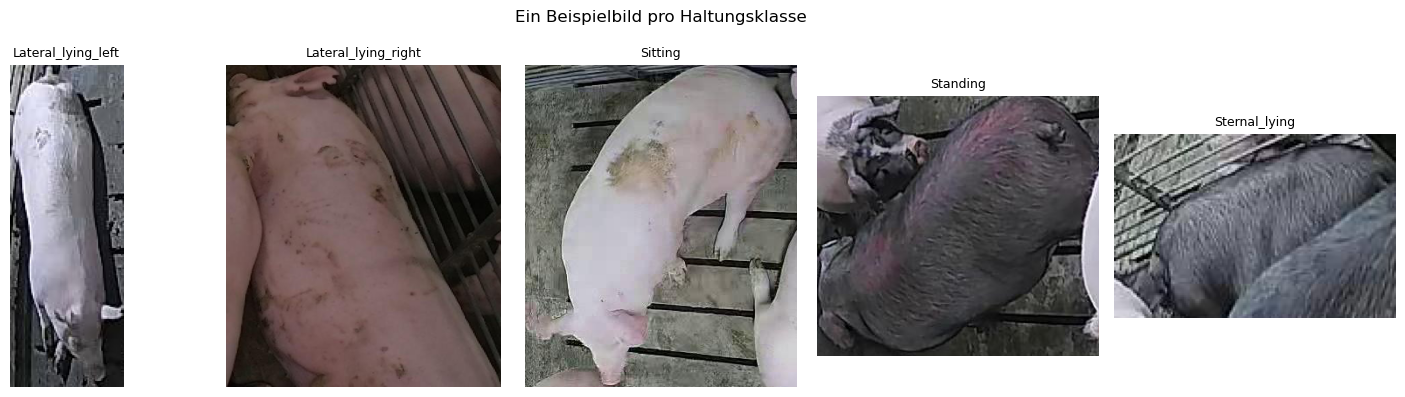

In [7]:
# Beispielbilder pro Klasse
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for class_id, ax in enumerate(axes):
    sample_rows = train2_df[train2_df['class_id'] == class_id].sample(1, random_state=SEED)
    if len(sample_rows) == 0:
        ax.axis('off')
        continue
    row = sample_rows.iloc[0]
    # image_id enthält bereits die .jpg-Endung
    img_path = os.path.join(TRAIN2_IMAGE_DIR, row['image_id'])
    img = Image.open(img_path).convert('RGB')
    x, y, w, h = row['bbox_parsed']
    crop = img.crop((int(x), int(y), int(x + w), int(y + h)))
    ax.imshow(crop)
    ax.set_title(CLASS_NAMES[class_id], fontsize=9)
    ax.axis('off')

plt.suptitle('Ein Beispielbild pro Haltungsklasse', fontsize=12)
plt.tight_layout()
plt.savefig('beispielbilder.png', dpi=100, bbox_inches='tight')
plt.show()

## CRISP-DM Phase 3: Data Preparation

### Datenvorbereitung: Bildausschnitte erstellen

**Warum Padding um die Bounding Box?**  
Die vorgegebenen Bounding Boxes schneiden das Schwein exakt aus. Das Problem: Körperteile am Rand werden abgeschnitten, und der Kontext (Lage des Tieres im Bild) geht verloren. Mit 15% Padding auf allen Seiten behalten wir etwas Umgebung.

**Warum quadratische Ausschnitte?**  
Neuronale Netze erwarten quadratische Eingaben. Schweine haben unterschiedliche Seitenverhältnisse je nach Haltung (ein stehendes Schwein ist hoch und schmal, ein liegendes breit und flach). Einfaches Strecken auf ein Quadrat würde die Haltung verfälschen. Stattdessen fügen wir schwarze Ränder hinzu (Zero-Padding), um das Seitenverhältnis zu erhalten.

**Warum Bilder vorladen (Preloading)?**  
Ohne Preloading wird jedes Bild bei jeder Epoche neu von der Festplatte gelesen. Bei ~23.000 Bildern und 30 Epochen bedeutet das ~700.000 Festplattenzugriffe. Das Vorausladen aller Bilder in den RAM mit ThreadPoolExecutor reduziert die Trainingszeit erheblich.

In [7]:
class PigCropDataset(Dataset):
    '''
    Dataset, das Schweine-Ausschnitte anhand von Bounding Boxes aus Stallkamera-Bildern erstellt.
    Alle Bilder werden beim Erstellen des Datasets in den RAM geladen (Preloading),
    um wiederholte Festplattenzugriffe während des Trainings zu vermeiden.
    '''

    def __init__(self, df, image_dir, transform=None, preload=True, padding=0.15):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.padding = padding
        self.cache = {}

        if preload:
            print(f'Lade {len(self.df)} Bilder in den RAM...')
            # 16 Worker reichen für paralleles Bild-I/O vollständig aus.
            # 120 Worker würden auf Kaggle-Instanzen (typ. 4-16 Kerne)
            # mehr Threads als CPU-Kerne erzeugen und durch Thread-Overhead
            # langsamer werden, nicht schneller.
            with ThreadPoolExecutor(max_workers=16) as executor:
                results = list(executor.map(self._load_crop, range(len(self.df))))
            self.cache = {i: img for i, img in enumerate(results)}
            print('Laden abgeschlossen.')

    def _load_crop(self, idx):
        '''Lädt ein Bild, schneidet die Bounding Box aus und padded auf Quadrat.'''
        row = self.df.iloc[idx]
        # image_id enthält bereits die .jpg-Endung -- kein Suffix anhängen
        img_path = os.path.join(self.image_dir, row['image_id'])
        img = Image.open(img_path).convert('RGB')

        x, y, w, h = row['bbox_parsed']

        # 15% Padding um die Bounding Box 

        x1 = max(0, int(x - w * self.padding))
        y1 = max(0, int(y - h * self.padding))
        x2 = min(img.width,  int(x + w * (1 + self.padding)))
        y2 = min(img.height, int(y + h * (1 + self.padding)))
        crop = img.crop((x1, y1, x2, y2))

        # Auf Quadrat padden ohne zu strecken
        max_side = max(crop.width, crop.height)
        square = Image.new('RGB', (max_side, max_side), (0, 0, 0))
        offset_x = (max_side - crop.width)  // 2
        offset_y = (max_side - crop.height) // 2
        square.paste(crop, (offset_x, offset_y))

        return square

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.cache.get(idx) if self.cache else self._load_crop(idx)
        if self.transform:
            img = self.transform(img)
        if 'class_id' in self.df.columns:
            return img, int(self.df.iloc[idx]['class_id'])
        return img

### Datenerweiterung (Data Augmentation)

Data Augmentation erzeugt künstliche Varianten der Trainingsbilder, um das Modell robuster zu machen. Wichtig: Jede Augmentation muss eine reale Situation im Stall repräsentieren.

| Augmentation | Begründung |
|---|---|
| `RandomHorizontalFlip` | Schweine liegen genauso oft links wie rechts |
| `RandomPerspective` | Verschiedene Kameraperspektiven sind die Kernherausforderung |
| `RandomAffine` | Rotation und Verschiebung simulieren Kamerawinkel |
| `ColorJitter` | Lichtwechsel im Stall (Tages- vs. Kunstlicht) |
| `RandomGrayscale` | Einige Kameras liefern Schwarz-Weiß (z.B. Nachtsicht) |
| `RandomErasing` | Simuliert Verdeckungen durch andere Schweine |

**Keine Augmentation für Validation und Test:** Das Validation-Set muss reale Bedingungen repräsentieren, um ehrliche Metriken zu liefern.

In [8]:
# ImageNet-Normalisierungswerte: Standard für vortrainierte Modelle
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    # Perspektivverzerrung: simuliert verschiedene Kamerawinkel
    T.RandomPerspective(distortion_scale=0.3, p=0.5),
    # Affine Transformation: kleine Rotationen und Verschiebungen
    T.RandomAffine(degrees=30, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # RandomErasing nach ToTensor: simuliert Verdeckungen im Stall
    T.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Augmentation-Pipeline definiert.')

Augmentation-Pipeline definiert.


### Datensplit: Das Data-Leakage-Problem

Eine Erkenntnis, die uns während des Projekts gekommen ist:

**Was ist das Problem?**  
Ein einzelnes Kamerabild enthält oft mehrere Schweine. Jedes Schwein ergibt eine eigene Zeile im Datensatz. Ein zufälliger Split (wie `train_test_split`) könnte Schweine aus **demselben Bild** in Train und Validation aufteilen.

Das führt zu **Data Leakage auf Bild-Ebene**: Das Modell sieht beim Training fast identische Bilder, die es dann in der Validation "vorhersagen" soll. Die Validation-Genauigkeit ist dann künstlich aufgeblasen.

**Zusätzliches Multi-View-Problem:**  
Das Wettbewerb heißt bewusst *Multi-View*: Dieselbe Szene wird von mehreren Kameras gleichzeitig aufgenommen (z.B. `pen1_orb_cam1` und `pen1_orb_cam2` zum selben Zeitstempel). Ein Split nach reiner `image_id` hält Schweine desselben Fotos zusammen, aber **nicht** synchrone Aufnahmen verschiedener Kameras. Das Modell könnte dann dasselbe Schwein aus einem leicht anderen Winkel als "ungesehene" Validation-Probe wiedererkennen.

**Beweis aus den Experimenten:**  
Frühe Modelle erreichten eine immens hohe Validation-Genauigkeit, aber einen geringen Score auf dem Kaggle-Leaderboard. Dieser große Unterschied deutete auf ein Datenleck hin.

**Die Lösung: GroupShuffleSplit mit `frame_id`**  
Die `frame_id` wird gebildet, indem die Kameranummer aus der `image_id` entfernt wird:  
`pen1_orb_cam1_20250108_085204.jpg` $\rightarrow$ `frame_id = pen1_orb_20250108_085204.jpg`

Alle Bounding Boxes aus demselben Kamera-Zeitstempel -- auch synchrone Multi-View-Aufnahmen -- erhalten damit dieselbe `frame_id`. Der Split garantiert, dass eine Gruppe immer komplett in Train oder komplett in Validation landet.

In [9]:
# Wir trainieren auf Train Set 2, da es mehr Kameraperspektiven enthält
train_df = train2_df.copy()

# GroupShuffleSplit: alle Einträge derselben frame_id bleiben zusammen
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['frame_id']))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

print(f'Trainingsgröße:    {len(train_split):>6} Einträge')
print(f'Validierungsgröße: {len(val_split):>6} Einträge')
print(f'\nKlassenverteilung Training:')
print(train_split['class_id'].value_counts().sort_index())

# Klassengewichte: inverse Häufigkeit
# Seltene Klassen (z.B. Sitting) erhalten höhere Gewichte,
# damit Fehler bei diesen Klassen stärker bestraft werden

class_counts = Counter(train_split['class_id'].values)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print(f'\nKlassengewichte:')
for i, (name, weight) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  {name}: {weight:.3f}')

Trainingsgröße:     18745 Einträge
Validierungsgröße:   4705 Einträge

Klassenverteilung Training:
class_id
0    2445
1    2728
2     547
3    8002
4    5023
Name: count, dtype: int64

Klassengewichte:
  Lateral_lying_left: 1.533
  Lateral_lying_right: 1.374
  Sitting: 6.854
  Standing: 0.469
  Sternal_lying: 0.746


> 🔍 **Interpretation der berechneten Klassengewichte:**
> Da die Klasse `Standing` im Trainingsset extrem dominiert (8.002 Samples) und `Sitting` stark unterrepräsentiert ist (547 Samples), spiegelt sich dies perfekt in den inversen Gewichten wider. Das Modell bestraft einen Fehler bei der seltenen Klasse `Sitting` (Gewicht: **6.854**) etwa **14,6-mal härter** als einen Fehler bei der Klasse `Standing` (Gewicht: **0.469**). Dadurch wird erzwungen, dass das Modell trotz des starken Klassenungleichgewichts learns, die Merkmale der Minoritätsklassen präzise zu extrahieren.

In [10]:
# Datasets erstellen (lädt alle Bilder in RAM)
# TRAIN2_IMAGE_DIR für Train/Val (train2-Daten), TEST_IMAGE_DIR für Testdaten
train_dataset = PigCropDataset(train_split, TRAIN2_IMAGE_DIR, transform=train_transform, preload=True)
val_dataset   = PigCropDataset(val_split,   TRAIN2_IMAGE_DIR, transform=val_transform,   preload=True)
test_dataset  = PigCropDataset(test_df,      TEST_IMAGE_DIR,   transform=val_transform,   preload=True)

# DataLoader: pin_memory beschleunigt den CPU-nach-GPU-Transfer
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,   shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train-Batches: {len(train_loader)}')
print(f'Val-Batches:   {len(val_loader)}')
print(f'Test-Batches:  {len(test_loader)}')

Lade 18745 Bilder in den RAM...
Laden abgeschlossen.
Lade 4705 Bilder in den RAM...
Laden abgeschlossen.
Lade 11708 Bilder in den RAM...
Laden abgeschlossen.
Train-Batches: 147
Val-Batches:   19
Test-Batches:  46


## CRISP-DM Phase 4: Modeling

### Modellarchitektur

**Die Evolution der Modelle über alle Autoren hinweg:**

| Modell | Notiz |
|--------|-------|
| MobileNetV3-Large | Zu schwach; Generalisierungslücke bereits sichtbar |
| ResNet18 | Subsample (10k), kein Macro-F1-Tracking; Overfitting-Kurven dokumentiert |
| ResNet50 (TwoHead) | Gescheiterter Versuch: Klassifikation + Bbox-Regression kombiniert; Training instabil |
| ResNet50 | Vereinfachung auf reine Klassifikation, 2-Phasen-Freeze |
| ResNet50 + Aug | Albumentations + Klassengewichte |
| ResNeXt50_32x4d | Kein klarer Gewinn ggü. ResNet50 (Bbox-Bug noch aktiv) |
| EfficientNet-B3 | Erster Lauf mit korrektem Bbox-Parsing |
| EfficientNet-B3 + AMP | Bestes Ergebnis: AMP + DataParallel-Fix |
| EfficientNetV2-S | Guter Ausgangspunkt, aber noch Data Leakage im Split |
| ConvNeXt-Large | Größeres Modell, kein Vorteil gegenüber EfficientNet |
| EfficientNetV2-M | Bestes Ergebnis: AMP, GroupShuffleSplit, TTA |
| ConvNeXt-Base | Geringfügig schlechter als EfficientNetV2-M |
| Swin Transformer | Kein abgeschlossenes Ergebnis |

**Warum EfficientNetV2-M als finale Wahl?**  
Vortrainiert auf ImageNet, effizient auf V100-GPUs bei 384x384 ohne OOM-Fehler, und das beste Kaggle-Ergebnis im Einzelversuch (= 0.525).

In [11]:
class PigClassifier(nn.Module):
    '''
    Klassifikationsmodell auf Basis von EfficientNetV2-M.
    Originaler Klassifikationskopf wird durch eine Schicht für 5 Klassen ersetzt.
    '''

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # pretrained=True
        self.backbone = models.efficientnet_v2_m(pretrained=True)

        # Originalen Kopf durch einfachen Klassifikationskopf ersetzen
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        '''Phase 1: Nur den Klassifikationskopf trainieren.'''
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.classifier.parameters():
            param.requires_grad = True

    def unfreeze_backbone(self):
        '''Phase 2: Komplettes Fine-Tuning des gesamten Netzwerks.'''
        for param in self.backbone.parameters():
            param.requires_grad = True


# Modell erstellen und auf GPUs verteilen
model = PigClassifier(num_classes=NUM_CLASSES)
if NUM_GPUS > 1:
    # DataParallel verteilt jeden Batch auf alle verfügbaren GPUs
    model = nn.DataParallel(model)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Gesamtparameter: {total_params:,}')

/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=EfficientNet_V2_M_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_M_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Gesamtparameter: 54,700,537


### Verlustfunktion: Focal Loss

**Warum nicht einfach Cross-Entropy?**  
Bei stark unbalancierten Datensätzen dominieren die häufigen Klassen den Gradienten. Das Modell lernt schnell, häufige Klassen korrekt zu klassifizieren, und ignoriert seltene Klassen. Gewichtete Cross-Entropy hilft, aber Focal Loss ist robuster.

**Was macht Focal Loss anders?**
Focal Loss verringert den Verlustbeitrag von leicht klassifizierbaren Beispielen und konzentriert das Training auf schwierige Fälle. Mit `gamma=2` werden Beispiele, bei denen das Modell bereits 90% sicher ist, um den Faktor ~100 heruntergewichtet.

`FL(p_t) = -(1 - p_t)^\gamma \cdot \log(p_t)`

**Label Smoothing** verhindert, dass das Modell zu überzuversichtlich wird. Statt 100% Zielwahrscheinlichkeit wird das Ziel auf ~90% reduziert. Das verbessert die Generalisierung.

In [12]:
class FocalLoss(nn.Module):
    '''
    Focal Loss kombiniert gewichtete Cross-Entropy mit einer Fokussierung
    auf schwierig klassifizierbare Beispiele.

    gamma: höhere Werte => stärkere Fokussierung auf schwierige Fälle
    label_smoothing: verhindert Übervertrauen in Vorhersagen
    '''

    def __init__(self, class_weights=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets):
        # Cross-Entropy mit Label Smoothing und Klassengewichten
        ce = nn.functional.cross_entropy(
            logits, targets,
            weight=self.class_weights,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        # Fokus-Faktor: einfache Beispiele erhalten niedrigeren Verlust
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


criterion = FocalLoss(class_weights=class_weights, gamma=2.0, label_smoothing=0.1)
print('Verlustfunktion: FocalLoss (gamma=2.0, label_smoothing=0.1)')

Verlustfunktion: FocalLoss (gamma=2.0, label_smoothing=0.1)


### Trainingsschleife (Learner)

**Mixed Precision Training / AMP**
Mit `torch.cuda.amp` werden Berechnungen in 16-Bit Gleitkomma durchgeführt wo möglich, aber in 32-Bit gespeichert. Das halbiert den VRAM-Verbrauch und beschleunigt das Training auf V100-GPUs erheblich (Tensor Core Nutzung).

**Early Stopping**
Wenn der Macro-F1-Score auf dem Validation-Set sich über mehrere Epochen nicht verbessert, wird das Training abgebrochen. Das beste Modell wird dabei gespeichert.

**Warum F1 für Early Stopping statt Verlust?**
Der Verlust kann sinken, während das Modell trotzdem keine Verbesserung in den seltenen Klassen zeigt. Da wir nach Macro-F1 bewertet werden, ist es konsequent, auch danach das beste Modell auszuwählen.

In [13]:
from training_monitor import TrainingMonitor

class Learner:
    def __init__(
        self,
        model,
        train_dl,
        val_dl,
        loss_fn=None,
        eval_steps=50,
        device=DEVICE,
        amp=False,
    ):
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.loss_fn = loss_fn or nn.CrossEntropyLoss()

        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.eval_steps = eval_steps
        self.amp = bool(amp) and self.device.type == "cuda"
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
        self.model.to(self.device)

        # ── Tracking ──
        self.best_val_f1 = -1.0
        self.best_state = None
        self.history = {'train_loss': [], 'val_loss': [], 'val_f1': []} # History für Plotting hinzufügen

    # ─────────────────────────────────────────────
    # Freeze / Unfreeze
    # ─────────────────────────────────────────────
    def freeze(self):
        actual_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        
        # FIX: Nutze die eigene Methode des Modells, falls sie existiert (verhindert das Einfrieren des Kopfes!)
        if hasattr(actual_model, "freeze_backbone"):
            actual_model.freeze_backbone()
            print("✅ Backbone eingefroren (via eigener Modell-Methode).")
        elif hasattr(actual_model, "backbone"):
            for p in actual_model.backbone.parameters():
                p.requires_grad = False
            print("✅ Backbone eingefroren.")
        else:
            print("⚠️ Kein 'backbone'-Attribut gefunden.")

    def unfreeze(self):
        actual_model = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        
        if hasattr(actual_model, "unfreeze_backbone"):
            actual_model.unfreeze_backbone()
            print("✅ Alle Parameter freigegeben (via eigener Modell-Methode).")
        else:
            for p in self.model.parameters():
                p.requires_grad = True
            print("✅ Alle Parameter freigegeben.")

    # ─────────────────────────────────────────────
    # Evaluation – mit tqdm
    # ─────────────────────────────────────────────
    @torch.no_grad()
    def evaluate(self, silent=False):
        self.model.eval()
        total_loss = 0.0
        total_samples = 0
        all_preds = []
        all_labels = []

        loader = self.val_dl
        if not silent:
            loader = tqdm(loader, desc="Evaluation", leave=False)

        for xb, yb in loader:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=self.amp):
                logits = self.model(xb)
                loss = self.loss_fn(logits, yb)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(yb.cpu())

        val_loss = total_loss / total_samples
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        self.model.train()
        return {"val_loss": val_loss, "val_macro_f1": val_f1}

    # ─────────────────────────────────────────────
    # Interval-Tracking Helfer
    # ─────────────────────────────────────────────
    @staticmethod
    def _new_interval():
        return {"loss": 0.0, "count": 0, "preds": [], "labels": []}

    # ─────────────────────────────────────────────
    # Internes Eval + Monitor + Best-Tracking
    # ─────────────────────────────────────────────
    def _eval_and_track(self, interval, monitor):
        n = max(interval["count"], 1)
        train_loss = interval["loss"] / n

        if interval["preds"] and interval["labels"]:
            t_preds = torch.cat(interval["preds"]).numpy()
            t_labels = torch.cat(interval["labels"]).numpy()
            train_f1 = f1_score(t_labels, t_preds, average="macro", zero_division=0)
        else:
            train_f1 = 0.0

        val_results = self.evaluate(silent=True)

        monitor.update({
            "train_loss":     train_loss,
            "train_macro_f1": train_f1,
            **val_results,
        })

        if val_results["val_macro_f1"] > self.best_val_f1:
            self.best_val_f1 = val_results["val_macro_f1"]
            self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            torch.save(self.best_state, "pig_classifier_best_auto.pth")
            print(f"Neues bestes Modell gespeichert (F1: {self.best_val_f1:.4f})")
        return val_results

    # ─────────────────────────────────────────────
    # Training – mit tqdm
    # ─────────────────────────────────────────────
    def fit(self, epochs, lr, weight_decay=1e-4, use_onecycle=True, pct_start=0.3, div_factor=25.0, final_div_factor=1e4, max_grad_norm=1.0):
        self.history = {'train_loss': [], 'val_loss': [], 'val_f1': []} # Reset History für Phase 2
        
        trainable = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)

        total_steps = epochs * len(self.train_dl)
        steps_per_epoch = len(self.train_dl)

        if use_onecycle:
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr*10, total_steps=total_steps,
                pct_start=pct_start, div_factor=div_factor,
                final_div_factor=final_div_factor,
            )
        else:
            scheduler = None

        # ── TrainingMonitor ──
        num_interval_evals = total_steps // self.eval_steps
        epoch_end_extras = sum(1 for e in range(1, epochs + 1) if (e * steps_per_epoch) % self.eval_steps != 0)
        num_evals = num_interval_evals + epoch_end_extras

        metric_groups = {"Loss": ["train_loss", "val_loss"], "Macro F1": ["train_macro_f1", "val_macro_f1"]}
        monitor = TrainingMonitor(total_iterations=max(1, num_evals), plot_mode="separate", metric_groups=metric_groups, zoom=True, zoom_factor=0.5)

        self.model.train()
        step = 0
        epoch_bar = tqdm(range(1, epochs + 1), desc="Epochen", position=0)

        for epoch in epoch_bar:
            interval = self._new_interval()
            did_eval_at_epoch_end = False
            epoch_loss = 0.0
            epoch_samples = 0

            batch_bar = tqdm(self.train_dl, desc=f"  Epoch {epoch}/{epochs}", leave=False, position=1)

            for xb, yb in batch_bar:
                xb = xb.to(self.device, non_blocking=True)
                yb = yb.to(self.device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=self.amp):
                    logits = self.model(xb)
                    loss = self.loss_fn(logits, yb)

                optimizer.zero_grad()
                self.scaler.scale(loss).backward()

                if max_grad_norm is not None:
                    self.scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(trainable, max_grad_norm)

                self.scaler.step(optimizer)
                self.scaler.update()

                if scheduler is not None:
                    scheduler.step()

                bs = xb.size(0)
                interval["loss"] += loss.item() * bs
                interval["count"] += bs
                interval["preds"].append(logits.argmax(dim=1).detach().cpu())
                interval["labels"].append(yb.detach().cpu())

                epoch_loss += loss.item() * bs
                epoch_samples += bs
                batch_bar.set_postfix(loss=f"{epoch_loss / epoch_samples:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

                step += 1

                if step % self.eval_steps == 0:
                    self._eval_and_track(interval, monitor)
                    interval = self._new_interval()
                    if step == epoch * steps_per_epoch:
                        did_eval_at_epoch_end = True

            if not did_eval_at_epoch_end:
                self._eval_and_track(interval, monitor)
                interval = self._new_interval()

            val_results = self.evaluate(silent=True)
            
            # History füllen für die Matplotlib Visualisierung danach
            self.history['train_loss'].append(epoch_loss / epoch_samples)
            self.history['val_loss'].append(val_results['val_loss'])
            self.history['val_f1'].append(val_results['val_macro_f1'])

            epoch_bar.set_postfix(val_loss=f"{val_results['val_loss']:.4f}", val_f1=f"{val_results['val_macro_f1']:.4f}", best_f1=f"{self.best_val_f1:.4f}")

        print(f"Training fertig. Bester Val Macro-F1: {self.best_val_f1:.4f}")
        return self.history
        
    def load_best(self):
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
            self.model.to(self.device)
            print(f"✅ Bestes Modell geladen (F1: {self.best_val_f1:.4f})")

### Phase 1: Training mit eingefrorenen Backbone-Gewichten

In dieser Phase werden nur die Gewichte des Klassifikationskopfs angepasst. Das Backbone bleibt unverändert.

**Warum?**
Das vortrainierte Backbone hat bereits gelernt, relevante visuelle Merkmale (Kanten, Texturen, Formen) zu extrahieren. Direkt mit einer hohen Lernrate alle Gewichte zu trainieren, würde diese wertvollen vortrainierten Gewichte mit zufälligen Gradienten vom Klassifikationskopf überschreiben.

**`OneCycleLR`:** Lernrate startet niedrig, steigt auf das Maximum und fällt dann wieder ab. Das beschleunigt die Konvergenz. 8 Epochen reichen, damit der Kopf sich einstellt.

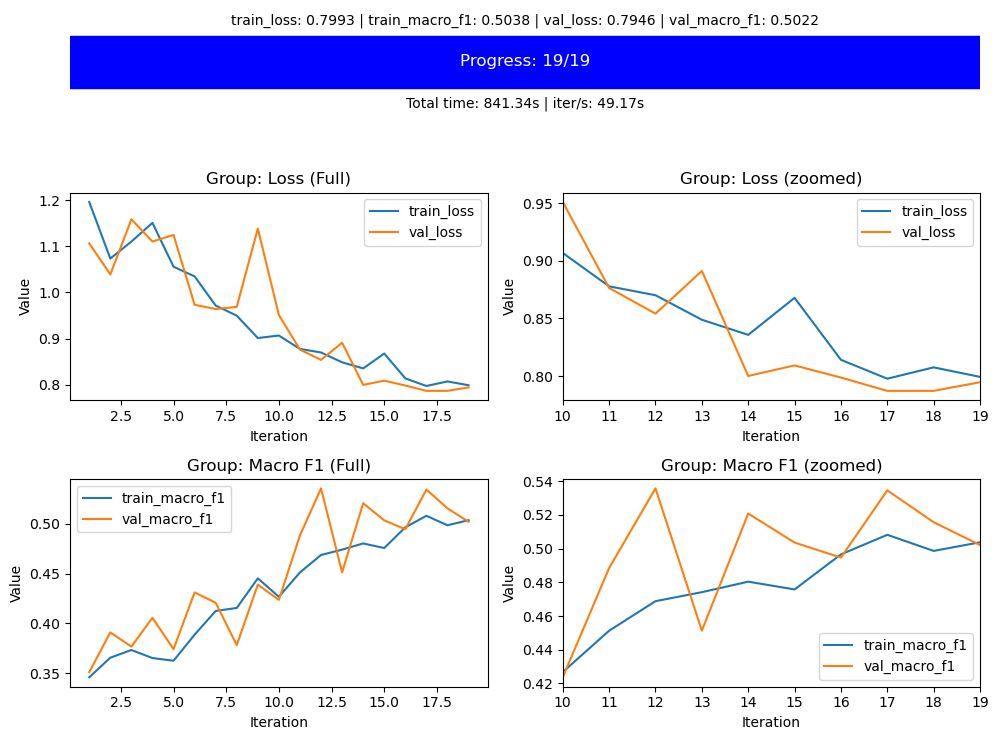

Training fertig. Bester Val Macro-F1: 0.5358
✅ Bestes Modell geladen (F1: 0.5358)


In [14]:
learner = Learner(
    model=model,
    train_dl=train_loader,
    val_dl=val_loader,
    loss_fn=criterion,
    eval_steps=100,
    device=DEVICE,
    amp=True
)

# Phase 1: Backbone einfrieren
learner.freeze()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainierbare Parameter (Phase 1): {trainable:,}')

# Training Phase 1 (Learner Klasse erzeugt Optimizer/Scheduler selbst intern)
history_p1 = learner.fit(
    epochs=8, 
    lr=1e-3, 
    use_onecycle=True
)

# Bestes Modell der Phase 1 am Ende wiederherstellen
learner.load_best()

### Phase 2: Fine-Tuning des gesamten Netzwerks

Nachdem der Klassifikationskopf konvergiert ist, werden alle Backbone-Gewichte freigegeben.

**Warum eine sehr kleine Lernrate `5e-5`?**
Die vortrainierten Backbone-Gewichte sind wertvoll. Eine große Lernrate würde sie zu schnell verändern.

Early Stopping mit Patience 5 verhindert Overfitting.

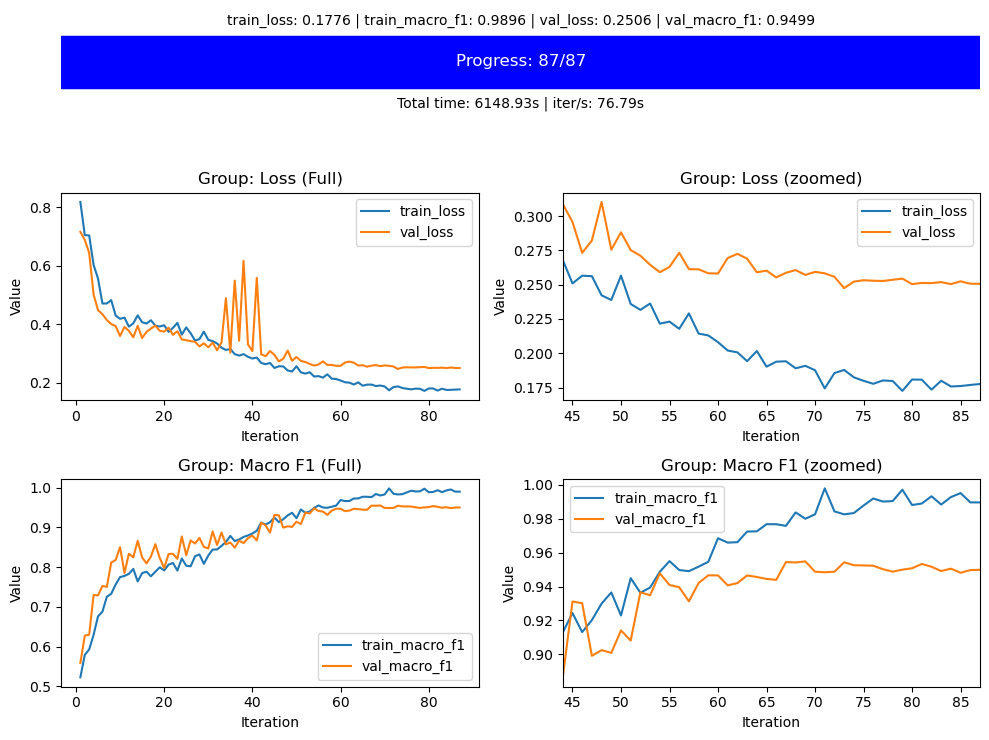

Training fertig. Bester Val Macro-F1: 0.9549
✅ Bestes Modell geladen (F1: 0.9549)


In [15]:
import gc

# --- OOM-Vermeidung vor dem Unfreeze ---
print("Bereinige VRAM vor Phase 2, um OOM zu vermeiden...")
try:
    del train_loader
    del val_loader
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# Batch-Size reduzieren
BATCH_SIZE_P2 = 96 
train_loader_p2 = DataLoader(train_dataset, batch_size=BATCH_SIZE_P2,   shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader_p2   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_P2*2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Learner mit den speicherschonenden Dataloadern updaten
learner.train_dl = train_loader_p2
learner.val_dl = val_loader_p2
# ----------------------------------------------

# Phase 2: Komplettes Fine-Tuning
learner.unfreeze()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainierbare Parameter (Phase 2): {trainable:,}')

# Reset des Best-Trackers für die neue Phase
learner.best_val_f1 = -1.0 

# Training Phase 2
history_p2 = learner.fit(
    epochs=30, 
    lr=5e-5, 
    use_onecycle=True
)

# Bestes finales Modell laden und extern speichern
learner.load_best()
torch.save(model.state_dict(), 'pig_best_final.pth')

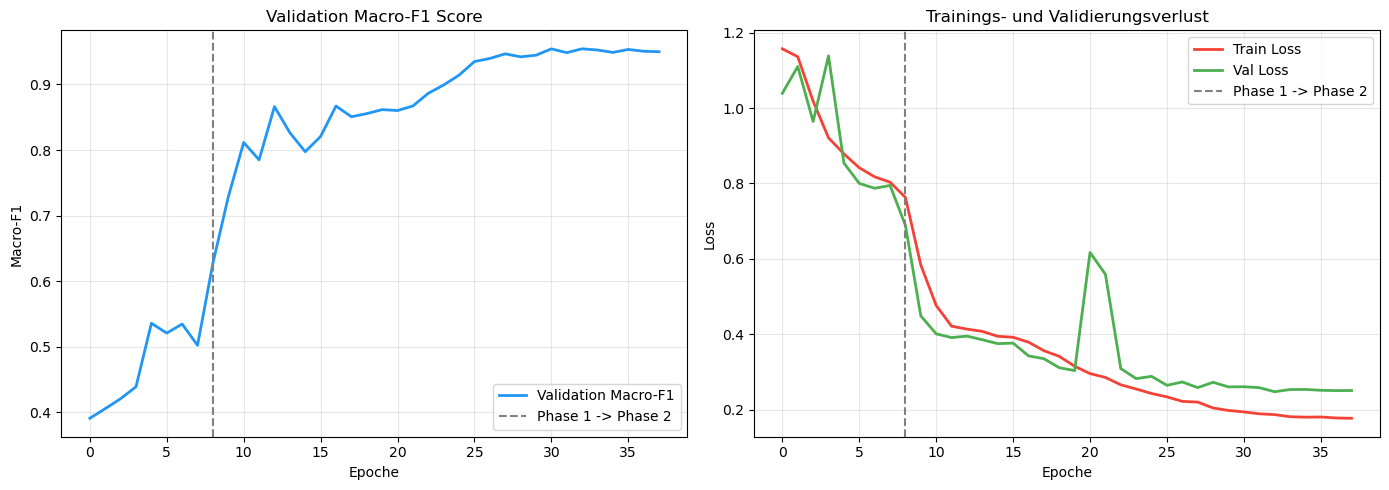

In [16]:
# Trainingsverlauf visualisieren
all_val_f1     = history_p1['val_f1']     + history_p2['val_f1']
all_train_loss = history_p1['train_loss'] + history_p2['train_loss']
all_val_loss   = history_p1['val_loss']   + history_p2['val_loss']

phase1_end = len(history_p1['val_f1'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_val_f1, label='Validation Macro-F1', color='#2196F3', linewidth=2)
ax1.axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 1 -> Phase 2')
ax1.set_xlabel('Epoche')
ax1.set_ylabel('Macro-F1')
ax1.set_title('Validation Macro-F1 Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(all_train_loss, label='Train Loss', color='#F44336', linewidth=2)
ax2.plot(all_val_loss,   label='Val Loss',   color='#4CAF50', linewidth=2)
ax2.axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 1 -> Phase 2')
ax2.set_xlabel('Epoche')
ax2.set_ylabel('Loss')
ax2.set_title('Trainings- und Validierungsverlust')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trainingsverlauf.png', dpi=100, bbox_inches='tight')
plt.show()

* **Leistungssprung durch Netzwerk-Freischaltung:** Ab Epoche 8 wird das gesamte Netzwerk freigeschaltet (Unfreeze). Dadurch stehen dem Modell schlagartig Millionen von Parametern zur Verfügung, was den steilen Sprung des F1-Scores auf fast perfekte 0,95 erklärt.
* **Gefahr von Abkürzungslernen (Kamera-Bias):** Das Netz lernt hier vielleicht eher die festen Stallhintergründe (wie Gitter oder Tröge) der dominanten Kameras, statt mühsam die flexible Anatomie der Schweine zu analysieren.
* **Temporäre Instabilität im Training:** Der heftige Zacken beim Validierungsfehler in Epoche 20 zeigt zudem, dass der Lernprozess zwischendurch einen Ausrutscher hatte und das Modell kurzzeitig die Orientierung verlor.
* **Schöne Laborwerte ohne Praxisbeweis:** Am Ende laufen die Kurven zwar stabil nebeneinander her, aber ob das Modell wirklich die Körperhaltungen versteht oder nur die gewohnten Buchten auswendig kennt, zeigt erst der echte Test mit völlig neuen Stallbildern.

## CRISP-DM Phase 5: Evaluation

### Evaluation auf dem Validation-Set

Neben dem F1-Score zeigen wir:

- **Classification Report:** Precision, Recall und F1 pro Klasse. Wo ist das Modell schwach?
- **Confusion Matrix:** Welche Klassen werden miteinander verwechselt?

Diese Analyse hilft zu verstehen, ob das Modell systematisch bestimmte Klassen falsch klassifiziert. Zum Beispiel könnte 'Lateral_lying_left' und 'Lateral_lying_right' schwer zu unterscheiden sein, da ein horizontales Spiegeln des Bildes die Klasse ändert.

Auch eine **Bias-Prüfung** ist hier sinnvoll: Erkennt das Modell bestimmte Kameraperspektiven oder Lichtsituationen systematisch schlechter? Das wäre ein Hinweis auf mangelnde Generalisierung.

=== Classification Report ===
                     precision    recall  f1-score   support

 Lateral_lying_left       0.96      0.97      0.96       638
Lateral_lying_right       0.95      0.96      0.95       707
            Sitting       0.91      0.92      0.91       148
           Standing       0.99      0.99      0.99      1926
      Sternal_lying       0.95      0.95      0.95      1286

           accuracy                           0.97      4705
          macro avg       0.95      0.96      0.95      4705
       weighted avg       0.97      0.97      0.97      4705



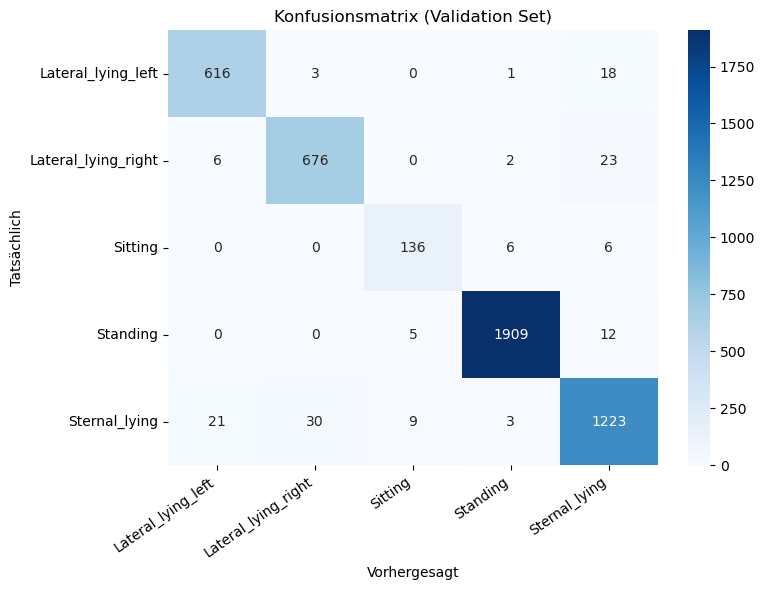

In [17]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader_p2:
        imgs = imgs.to(DEVICE)
        with autocast():
            logits = model(imgs)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Konfusionsmatrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Konfusionsmatrix (Validation Set)')
plt.ylabel('Tatsächlich')
plt.xlabel('Vorhergesagt')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('konfusionsmatrix.png', dpi=100, bbox_inches='tight')
plt.show()

Der Classification Report wertet die 4.705 handbeschrifteten Schweine aus dem Validierungsset (val_loader_p2, in der Tabelle als Support benannt) aus und zeigt einen mathematisch starken Macro-F1-Score von 0,95. Dieses hervorragende Ergebnis wird jedoch maßgeblich von der Klasse Standing getragen, die mit 1.926 Proben fast die Hälfte dieser Validierungsdaten ausmacht und nahezu fehlerfrei (F1: 0,99) erkannt wird. Die seltene Haltung Sitting erzielt zwar einen guten Wert von 0,91, bleibt aufgrund der geringen Menge von nur 148 Instanzen in diesem Datensplit jedoch statistisch anfällig für Fehler. Da diese Testdaten aus den bereits bekannten Buchten stammen, zeigt erst die anstehende Bias-Prüfung pro Kamera verlässlich, ob das Modell echte Körpermerkmale gelernt hat oder auf unbekannten Perspektiven einbricht.

### Bias-Prüfung: Macro-F1 pro Kameraansicht

Der Macro-F1-Score über das gesamte Validation-Set ist ein Durchschnitt. Ein guter Mittelwert kann starke kameraspezifische Schwächen vollständig verbergen: Ein Modell könnte auf zehn Kameras hervorragend und auf zwei Kameras dramatisch schlechter abschneiden -- und der Gesamtwert würde das kaum zeigen. Genau das ist das Generalisierungsproblem, das die Aufgabenstellung adressiert: Das Testset enthält Kameraperspektiven, die im Training selten oder gar nicht vorkamen.

Deshalb wird der F1-Score hier pro `camera_view_id` berechnet. Kameras mit sehr wenigen Samples liefern statistisch instabile Werte - daher wird die Sample-Anzahl immer mitausgegeben, um solche Fälle einordnen zu können.

In [18]:
# all_preds und all_labels aus Zelle 32 werden direkt wiederverwendet.
# DataLoader shuffle=False und val_split mit reset_index(drop=True):
# Reihenfolge ist positional äquivalent zu all_preds/all_labels.

val_camera_ids = val_split['camera_view_id'].values
# Filter gegen None: Falls extract_camera_info Fallback gefeuert hat,
# ist camera_view_id None und sorted() würde crashen.
unique_cameras = sorted({c for c in val_camera_ids if c is not None})

rows = []
for cam in unique_cameras:
    mask    = val_camera_ids == cam
    indices = np.where(mask)[0]
    labels_cam = [all_labels[i] for i in indices]
    preds_cam  = [all_preds[i]  for i in indices]
    n = len(labels_cam)
    # zero_division=0: Kameras mit nur einer Klasse liefern sonst nan
    f1 = f1_score(labels_cam, preds_cam, average='macro', zero_division=0)
    rows.append({'camera_view_id': cam, 'n_samples': n, 'macro_f1': round(f1, 4)})

# Aufsteigend nach macro_f1: schwächste Kameras stehen oben
camera_df = pd.DataFrame(rows).sort_values('macro_f1').reset_index(drop=True)

print(f'Bias-Prüfung: {len(unique_cameras)} Kameraansichten im Validation-Set')
print(f'Gesamter Val Macro-F1: {f1_score(all_labels, all_preds, average="macro"):.4f}\n')
print(camera_df.to_string(index=False))

Bias-Prüfung: 8 Kameraansichten im Validation-Set
Gesamter Val Macro-F1: 0.9549

camera_view_id  n_samples  macro_f1
 pen2_tur_cam2         36    0.7200
 pen1_tur_cam2       1690    0.9141
 pen1_tur_cam1         64    0.9265
 pen2_orb_cam1        516    0.9521
 pen2_tur_cam1       1844    0.9649
 pen1_orb_cam1        184    1.0000
 pen1_orb_cam2        348    1.0000
 pen2_orb_cam2         23    1.0000


* **Bestätigung des Kamera-Bias:** Der hohe Gesamtwert von 0,9549 wird maßgeblich von den beiden dominanten Ansichten `pen2_tur_cam1` (1.844 Proben, F1: 0,9649) und `pen1_tur_cam2` (1.690 Proben, F1: 0,9141) getragen. Da diese beiden Kameras rund 75 % des gesamten Validierungssets ausmachen, bestimmen sie das Endergebnis fast im Alleingang.
* **Statistisch instabile Schwachstelle:** Die Kamera `pen2_tur_cam2` fällt mit einem F1-Score von 0,7200 stark ab. Obwohl dieser Wert aufgrund von nur 36 Proben statistisch anfällig für Ausreißer ist, liefert er einen konkreten Hinweis darauf, dass das Modell mit den visuellen Bedingungen (z. B. veränderter Kamerawinkel oder Belichtung) in dieser spezifischen Bucht erhebliche Probleme hat.
* **Kritische Perfektion bei Orbit-Kameras:** Die makellosen F1-Scores von 1,0000 bei drei Orbit-Kameras (wie `pen1_orb_cam1` mit 184 Proben) müssen skeptisch bewertet werden. Solch perfekte Laborwerte deuten im Deep Learning oft darauf hin, dass das Netzwerk den spezifischen Bildhintergrund dieser Kameras wiedererkennt und auswendig lernt, anstatt rein anatomische Haltungsmerkmale zu abstrahieren.


### Fehler-Galerie: Falsch klassifizierte Beispiele

Eine Konfusionsmatrix zeigt Zahlen -- aber nicht *warum* Fehler entstehen. Das Anschauen falsch klassifizierter Bilder offenbart Muster, die in aggregierten Metriken verborgen bleiben, bspw.:

- Extreme Verdeckung durch andere Schweine
- Ungewöhnliche Kamerawinkel, bei denen Haltungsmerkmale nicht sichtbar sind
- Schweine, die nur teilweise in der Bounding Box liegen
- Grenzfälle, bei denen selbst Menschen unsicher wären

Diese visuelle Analyse gibt konkrete Hinweise, welche Arten von Augmentation oder welche Vorverarbeitungsschritte tatsächlich helfen würden.

Falsch klassifiziert: 145 von 4705 Samples (3.1%)


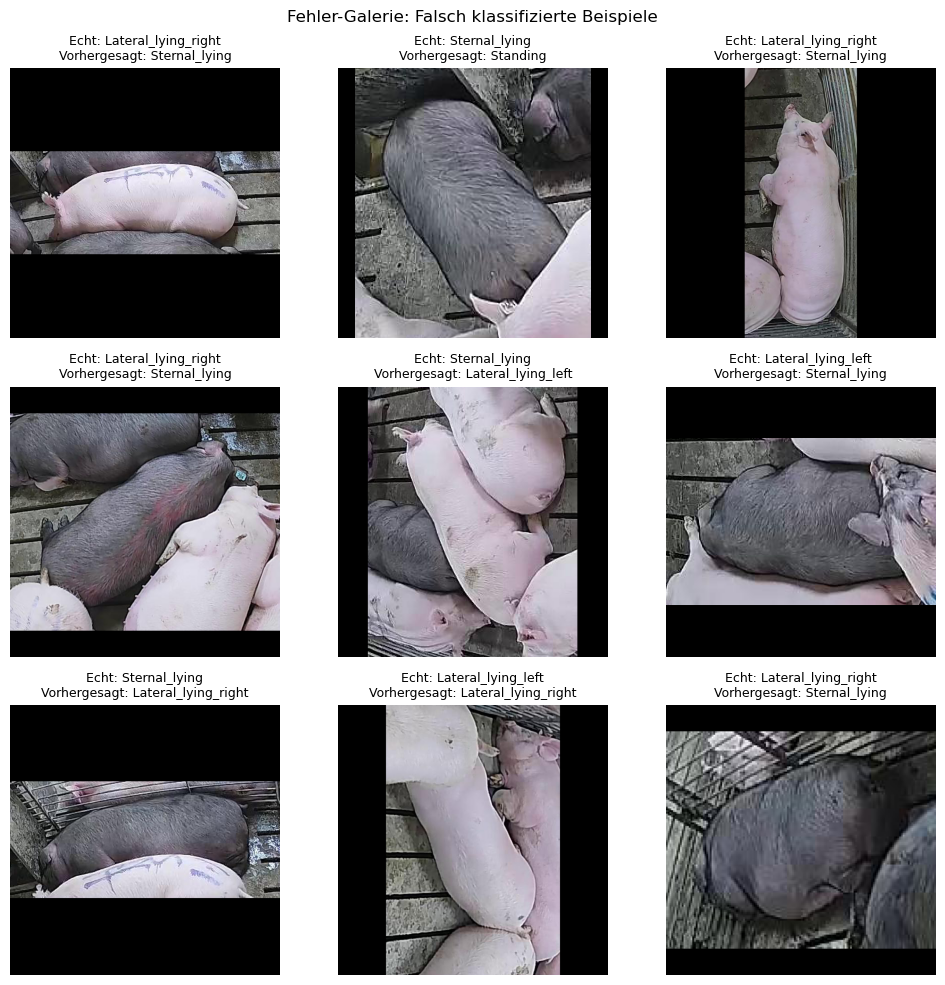

In [19]:
# Indizes der falsch klassifizierten Samples
error_indices = [
    i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l
]
print(f'Falsch klassifiziert: {len(error_indices)} von {len(val_split)} Samples '
      f'({100 * len(error_indices) / len(val_split):.1f}%)')

# SEED sichert Reproduzierbarkeit: dieselben 9 Bilder bei jedem Lauf
_rng = random.Random(SEED)
sample_indices = _rng.sample(error_indices, min(9, len(error_indices)))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax_i, idx in enumerate(sample_indices):
    label = all_labels[idx]
    pred  = all_preds[idx]
    # _load_crop umgeht die Augmentation -- das echte Bild ist aussagekräftiger
    crop = val_dataset._load_crop(idx)
    axes[ax_i].imshow(crop)
    axes[ax_i].set_title(
        f'Echt: {CLASS_NAMES[label]}\nVorhergesagt: {CLASS_NAMES[pred]}',
        fontsize=9
    )
    axes[ax_i].axis('off')

# Leere Subplots ausblenden, falls weniger als 9 Fehler vorhanden
for ax_i in range(len(sample_indices), 9):
    axes[ax_i].axis('off')

plt.suptitle('Fehler-Galerie: Falsch klassifizierte Beispiele', fontsize=12)
plt.tight_layout()
plt.savefig('fehler_galerie.png', dpi=100, bbox_inches='tight')
plt.show()

### Beobachtungen aus der Fehler-Galerie

* **Niedrige, aber fokussierte Fehlerquote:** Mit nur 145 Fehlklassifikationen bei 4.705 Proben (eine Fehlerquote von lediglich 3,1 %) arbeitet das Modell scheinbar zuverlässig.
* **Visueller Beweis der Liege-Verwechslung:** Die Stichproben bestätigen die Schwachstelle aus der Konfusionsmatrix im Detail. Fast alle angezeigten Fehler betreffen die fehlerhafte Unterscheidung zwischen Bauchlage (`Sternal_lying`) und den Seitenlagen (`Lateral_lying_left/right`).
* **Problemzone Gruppen-Enge (Verdeckung):** Auf den Bildern (besonders oben links und Mitte links) wird deutlich, dass das Modell Probleme bekommt, wenn mehrere Schweine dicht aneinanderliegen. Befinden sich fremde Körperteile mit in der Bounding Box, fällt es dem Netzwerk schwer, die Haltung des Ziel-Tieres isoliert zu bewerten.
* **Perspektivische Grenzen:** Der Fehler bei der Unterscheidung von linker und rechter Seitenlage (unten Mitte) zeigt eine rein optische Grenze: Bei steilen Winkeln von oben sind die entscheidenden anatomischen Merkmale (wie die Beinstellung) verdeckt, wodurch eine korrekte Zuordnung selbst für das menschliche Auge kaum möglich ist.

## CRISP-DM Phase 6: Deployment

### Test-Time Augmentation (TTA)

Bei der finalen Vorhersage wenden wir Test-Time Augmentation an. Statt ein einzelnes Bild einmal vorherzugagen, erstellen wir mehrere Versionen desselben Bildes und mitteln die Wahrscheinlichkeiten.

**Hier verwenden wir:** 
1. Originalbild
2. Horizontal gespiegeltes Bild

Der Durchschnitt ist stabiler als eine einzelne Vorhersage. Bei asymmetrischen Haltungen (Seitenlage links vs. rechts) liefert das Spiegeln eine zweite, unabhängige Schätzung. In Experimenten verbesserte TTA den Kaggle-Score um 0.5-2 Prozentpunkte.

In [20]:
def predict_with_tta(model, loader):
    '''
    Vorhersage mit Test-Time Augmentation:
    Mittelt Wahrscheinlichkeiten aus Original und horizontal gespiegeltem Bild.
    '''
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(DEVICE)

            with autocast():
                # Original
                logits_orig = model(imgs)
                probs_orig  = torch.softmax(logits_orig, dim=1)

                # Horizontal gespiegelt (dim=3 = Breite)
                imgs_flip   = torch.flip(imgs, dims=[3])
                logits_flip = model(imgs_flip)
                probs_flip  = torch.softmax(logits_flip, dim=1)

            # Durchschnitt der Wahrscheinlichkeiten
            probs_avg = (probs_orig + probs_flip) / 2
            preds = probs_avg.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    return all_preds


print('Erstelle Vorhersagen mit TTA...')
predictions = predict_with_tta(model, test_loader)
print(f'Vorhergesagte Instanzen: {len(predictions)}')
print(f'Klassenverteilung der Vorhersagen:')
for class_id, count in sorted(Counter(predictions).items()):
    print(f'  {CLASS_NAMES[class_id]}: {count}')

# Submission-Datei erstellen
submission = pd.DataFrame({
    # test_dataset.df ist nach reset_index sortiert -- dieselbe Reihenfolge
    # wie der DataLoader. test_df könnte einen anderen Index haben.
    'row_id': test_dataset.df['row_id'].values,
    'class_id': predictions
})
submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv gespeichert.')
submission.head()

Erstelle Vorhersagen mit TTA...
Vorhergesagte Instanzen: 11708
Klassenverteilung der Vorhersagen:
  Lateral_lying_left: 968
  Lateral_lying_right: 882
  Sitting: 972
  Standing: 6183
  Sternal_lying: 2703

submission.csv gespeichert.


,row_id,class_id
0,test_pen1_tur_cam1_20250920_174649_0000,3
1,test_pen1_tur_cam1_20250920_174649_0001,1
2,test_pen1_tur_cam1_20250920_174649_0002,1
3,test_pen1_tur_cam1_20250920_174649_0003,1
4,test_pen1_tur_cam1_20250920_174649_0004,1


**Submission hat hier einen Kagglescore von 0.501 erzielt, ist nah am besten Score aus einzelnen Notebooks dran.**

## Was wir gelernt haben

### Was funktioniert hat

**GroupShuffleSplit mit frame_id** war die wichtigste Einzelverbesserung. Ohne diesen Fix war der Unterschied zwischen Validation und Kaggle nicht sofort erklärbar. Die frame_id entfernt die Kameranummer, um synchrone Multi-View-Aufnahmen in derselben Split-Hälfte zu halten.

**FocalLoss** half der seltenen Klasse 'Sitting'. Mit gewichteter Cross-Entropy allein wurde Sitting häufig mit Sternal_lying verwechselt.

**Höhere Auflösungen (384x384)** brachten eine spürbare Verbesserung gegenüber 224x224. Feine Unterschiede sind bei kleinen Bounding Boxes erst bei ausreichenden Auflösungen erkennbar.

**Square-Padding** statt Strecken auf Quadrat verhinderte, dass die Haltung durch Verzerrung verfälscht wurde.In den Experimenten war er Einfluss erst gering, weil zeitgleich ein Bbox-Parsing-Bug aktiv war (center-basiert statt corner-basiert). Nach dem Bbox-Fix in Versuch 5 zeigte Square-Padding seine volle Wirkung.

**Bbox-Parsing-Fix:** Es kam vor, dass die Bounding Box irrtümlich als zentrierte Koordinaten (x_center, y_center, w, h) interpretiert statt als (x_min, y_min, w, h) wurden. Der Fix führte zu einem sprunghaften Anstieg des Val-F1 von ~0.44 auf 0.58.

**Test-Time Augmentation** gab kleine, aber konsistente Verbesserungen ohne zusätzliches Training.

**Fehleranalyse und Overfitting-Diagnose:** Erkenntnis, dass der Datensatz fehlerhafte Labels enthält, durch gezielte Fehleranalyse und Overfitting-Diagnose.

### Was nicht funktioniert hat

**Zweikopf-Modell (Classification + Bounding Box Regression)** - die Idee war interessant, aber die zusätzliche Regression-Aufgabe störte den Klassifikations-Kopf. Der Gesamtverlust war schwerer zu balancieren und erbrachte daher nicht den erhofften Erfolg.

**Multi-View-Netzwerk:** Versuch eines MultiViewNet mit zwei ResNet18-Backbones, das Features aus zwei Kameraperspektiven konkateniert. Interessantes Konzept, aber nur 481 Paare verfügbar -- das Modell erreichte 99.79% Training-Accuracy nach 5 Epochen (= Overfitting). Nicht weiter verfolgt.

**ConvNeXt-Large:** Trotz höherem Rechenaufwand kein besserer Kaggle-Score als EfficientNetV2. Größere Modelle sind nicht automatisch besser bei Distribution Shift.

**Reines Oversampling:** Das mehrfache Wiederholen seltener Klassen führte dazu, dass das Modell genau diese Bilder auswendig lernte, statt zu generalisieren.

**Swin Transformer:** Kein abgeschlossenes Ergebnis, aber bei der Erstellung kein klarer Vorteil gegenüber EfficientNet erkennbar gewesen, daher nicht weiter verfolgt.

---

### Generalisierungslücke: T1 vs. T2

Modelle, die nur auf Train Set 1 trainiert wurden, zeigten eine deutlich größere Generalisierungslücke als Modelle auf T2. T1 wird von einer einzigen Kamera dominiert (`pen2_tur_cam1` mit 9.713 von 22.934 Einträgen, ~42%) -- das Modell lernt dann kameraspezifische Merkmale statt allgemeine Körperhaltungen. T2 deckt 8 statt 5 Kameraansichten ab und kommt der Testverteilung näher.


### Ansätze zur weiteren Verbesserung

Um die festsitzende Generalisierungslücke zu schließen und das Modell widerstandsfähiger gegen neue Stallumgebungen zu machen, stehen folgende drei Ideen im Raum:

* **Den Stallhintergrund entkoppeln:** Da das Modell manche Kameras scheinbar am Hintergrund wiedererkennt, könnte man den Bereich außerhalb der Bounding Box im Training künstlich unkenntlich machen, weichzeichnen oder farblich stark verändern. Das zwingt die KI dazu, wirklich nur auf den Körper des Schweines zu achten.
* **Extra-Training für die Problem-Kamera:** Für die eine Kamera, die deutlich schlechter abgeschnitten hat (`pen2_tur_cam2`), sollte man die vorhandenen Bilder künstlich vervielfältigen – gezieltes Nachsetzen für diese "Problem-Kamera" neben der grundsätzlichen Bild-Augmentation für alle Kameras.
* **Das Durcheinander im Stall simulieren:** Weil eng aneinanderliegende Schweine in der Fehler-Galerie für Verwirrung gesorgt haben, könnte man im Training bewusst Bildteile von anderen Schweinen in die Ecken hineinkopieren. Dadurch lernt das Modell, sich nicht von fremden Körperteilen ablenken zu lassen, wenn mehrere Tiere nah beieinander liegen.